In [ ]:
!nvidia-smi

Mon Mar 16 18:45:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
%cd /content
!mkdir -p /content/data
%cd /content/data

# Download Task03_Liver
!wget -O Task03_Liver.tar https://msd-for-monai.s3-us-west-2.amazonaws.com/Task03_Liver.tar
!tar -xf Task03_Liver.tar
!ls -lah /content/data/Task03_Liver

/content
/content/data
--2026-03-16 18:45:14--  https://msd-for-monai.s3-us-west-2.amazonaws.com/Task03_Liver.tar
Resolving msd-for-monai.s3-us-west-2.amazonaws.com (msd-for-monai.s3-us-west-2.amazonaws.com)... 52.92.236.74, 52.92.235.178, 3.5.77.73, ...
Connecting to msd-for-monai.s3-us-west-2.amazonaws.com (msd-for-monai.s3-us-west-2.amazonaws.com)|52.92.236.74|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28925891584 (27G) [application/x-tar]
Saving to: ‘Task03_Liver.tar’

Task03_Liver.tar    100%[===================>]  26.94G  22.2MB/s    in 24m 28s 

2026-03-16 19:09:43 (18.8 MB/s) - ‘Task03_Liver.tar’ saved [28925891584/28925891584]

total 68K
drwxr-xr-x 5 root root  4.0K Mar 16 19:11 .
drwxr-xr-x 3 root root  4.0K Mar 16 19:09 ..
-rw-r--r-- 1  502 staff  451 Jul  3  2018 ._dataset.json
-rw-r--r-- 1  502 staff  13K Jul  3  2018 dataset.json
-rwxr-xr-x 1  502 staff  187 May 26  2018 ._imagesTr
drwxr-xr-x 2  502 staff  12K May 26  2018 imagesTr
-rwxr-xr-

In [ ]:
!pip -q install nibabel monai opencv-python matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 31.2 MB/s eta 0:00:00


In [ ]:
!pip -q install git+https://github.com/facebookresearch/segment-anything.git

  Preparing metadata (setup.py) ... done


In [ ]:
import torch, sys
print(torch.__version__)
print("CUDA:", torch.cuda.is_available())

2.10.0+cu128
CUDA: True


In [ ]:
import os
import numpy as np
import nibabel as nib

images_dir = "/content/data/Task03_Liver/imagesTr"
labels_dir = "/content/data/Task03_Liver/labelsTr"

img_files = sorted([os.path.join(images_dir, f) for f in os.listdir(images_dir) if f.endswith(".nii") or f.endswith(".nii.gz")])
lab_files = sorted([os.path.join(labels_dir, f) for f in os.listdir(labels_dir) if f.endswith(".nii") or f.endswith(".nii.gz")])

print("Images:", len(img_files), "Labels:", len(lab_files))
print("Example:", img_files[0], lab_files[0])

Images: 262 Labels: 262
Example: /content/data/Task03_Liver/imagesTr/._liver_0.nii.gz /content/data/Task03_Liver/labelsTr/._liver_0.nii.gz


In [ ]:
def window_ct_hu(slice_hu, level=50, width=400):
    low = level - width/2
    high = level + width/2
    x = np.clip(slice_hu, low, high)
    x = (x - low) / (high - low) * 255.0
    return x.astype(np.uint8)

def to_rgb(gray_u8):
    return np.stack([gray_u8, gray_u8, gray_u8], axis=-1)  # H,W,3

In [ ]:
def mask_to_box(mask2d):
    ys, xs = np.where(mask2d > 0)
    if len(xs) == 0:
        return None
    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()
    return np.array([x1, y1, x2, y2])

In [ ]:
!mkdir -p /content/checkpoints
!wget -O /content/checkpoints/sam_vit_b_01ec64.pth https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

--2026-03-16 19:12:05--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 54.230.79.122, 54.230.79.88, 54.230.79.93, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|54.230.79.122|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘/content/checkpoints/sam_vit_b_01ec64.pth’

/content/checkpoint 100%[===================>] 357.67M   324MB/s    in 1.1s    

2026-03-16 19:12:06 (324 MB/s) - ‘/content/checkpoints/sam_vit_b_01ec64.pth’ saved [375042383/375042383]



In [ ]:
!mkdir -p /content/checkpoints
!wget -O /content/checkpoints/sam_vit_b_01ec64.pth https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

--2026-03-16 19:12:06--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 54.230.79.122, 54.230.79.88, 54.230.79.93, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|54.230.79.122|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘/content/checkpoints/sam_vit_b_01ec64.pth’

/content/checkpoint 100%[===================>] 357.67M   270MB/s    in 1.3s    

2026-03-16 19:12:07 (270 MB/s) - ‘/content/checkpoints/sam_vit_b_01ec64.pth’ saved [375042383/375042383]



In [ ]:
import torch
from segment_anything import sam_model_registry, SamPredictor

device = "cuda" if torch.cuda.is_available() else "cpu"
sam = sam_model_registry["vit_b"](checkpoint="/content/checkpoints/sam_vit_b_01ec64.pth")
sam.to(device=device)
predictor = SamPredictor(sam)

def run_sam_on_slice(rgb_img, box_xyxy):
    predictor.set_image(rgb_img)
    masks, scores, logits = predictor.predict(
        box=box_xyxy[None, :],  # shape (1,4)
        multimask_output=False
    )
    return masks[0].astype(np.uint8)

In [ ]:
def dice(pred, gt, eps=1e-8):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    inter = (pred & gt).sum()
    return (2*inter + eps) / (pred.sum() + gt.sum() + eps)

def iou(pred, gt, eps=1e-8):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    inter = (pred & gt).sum()
    union = (pred | gt).sum()
    return (inter + eps) / (union + eps)

In [ ]:
images_dir = "/content/data/Task03_Liver/imagesTr"
labels_dir = "/content/data/Task03_Liver/labelsTr"

img_files = sorted([
    os.path.join(images_dir, f)
    for f in os.listdir(images_dir)
    if f.endswith(".nii.gz") and not f.startswith("._")
])

lab_files = sorted([
    os.path.join(labels_dir, f)
    for f in os.listdir(labels_dir)
    if f.endswith(".nii.gz") and not f.startswith("._")
])

print("Images:", len(img_files))
print("Labels:", len(lab_files))
print("Example:", img_files[0])

Images: 131
Labels: 131
Example: /content/data/Task03_Liver/imagesTr/liver_0.nii.gz


In [ ]:
!find /content/data/Task03_Liver -name "._*" -delete

In [ ]:
!ls /content/data/Task03_Liver/imagesTr | head

liver_0.nii.gz
liver_100.nii.gz
liver_101.nii.gz
liver_102.nii.gz
liver_103.nii.gz
liver_104.nii.gz
liver_105.nii.gz
liver_106.nii.gz
liver_107.nii.gz
liver_108.nii.gz


In [ ]:
for img_path, lab_path in tqdm(list(zip(img_files, lab_files))):
    img = nib.load(img_path).get_fdata()
    lab = nib.load(lab_path).get_fdata()

100%|██████████| 131/131 [08:06<00:00,  3.71s/it]


In [ ]:
img = nib.load(img_files[0]).get_fdata()
lab = nib.load(lab_files[0]).get_fdata()

print(img.shape, lab.shape)

(512, 512, 75) (512, 512, 75)


In [ ]:
import numpy as np
import nibabel as nib
from tqdm import tqdm
import os

def collect_nonempty_slices(img_files, lab_files, max_slices=None, seed=0):
    """
    Returns a list of (img_path, lab_path, z_index) only for slices where GT>0.
    If max_slices is set, subsamples uniformly for speed/fairness.
    """
    triples = []
    for img_path, lab_path in tqdm(list(zip(img_files, lab_files)), desc="Indexing non-empty slices"):
        img = nib.load(img_path)
        lab = nib.load(lab_path).get_fdata()
        for z in range(lab.shape[-1]):
            if (lab[..., z] > 0).sum() > 0:
                triples.append((img_path, lab_path, z))

    if max_slices is not None and len(triples) > max_slices:
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(triples), size=max_slices, replace=False)
        triples = [triples[i] for i in idx]

    return triples

In [ ]:
PERTURBATIONS = {
    "Noise(sigma)": [0, 5, 10, 20, 30],
    "Blur(k)":      [0, 3, 5, 7, 9],
    "DownUp(scale)":[1.0, 0.75, 0.5, 0.35, 0.25],
    "Gamma":        [1.0, 0.8, 0.6, 1.2, 1.5],
    "Contrast(a)":  [1.0, 0.8, 0.6, 1.2, 1.5],
}

In [ ]:
def apply_perturb(gray_u8, ptype, val):
    if ptype == "Noise(sigma)":
        return gray_u8 if val == 0 else add_gaussian_noise(gray_u8, sigma=val)
    if ptype == "Blur(k)":
        return gray_u8 if val == 0 else gaussian_blur(gray_u8, k=int(val))
    if ptype == "DownUp(scale)":
        return gray_u8 if val == 1.0 else down_up(gray_u8, scale=float(val))
    if ptype == "Gamma":
        return gray_u8 if val == 1.0 else gamma_correction(gray_u8, gamma=float(val))
    if ptype == "Contrast(a)":
        return gray_u8 if val == 1.0 else contrast_scale(gray_u8, alpha=float(val))
    raise ValueError("Unknown perturbation type")

In [ ]:
def eval_organ_curves(triples, organ_name):
    curves = {}  # ptype -> list of (severity, mean_dice)
    for ptype, severities in PERTURBATIONS.items():
        mean_dices = []

        for sev in severities:
            dices = []
            for (img_path, lab_path, z) in tqdm(triples, desc=f"{organ_name} | {ptype}={sev}", leave=False):
                img = nib.load(img_path).get_fdata()
                lab = nib.load(lab_path).get_fdata()

                gt = (lab[..., z] > 0).astype(np.uint8)
                box = mask_to_box(gt)
                if box is None:
                    continue

                gray = window_ct_hu(img[..., z], level=50, width=400)
                gray_p = apply_perturb(gray, ptype, sev)
                rgb = to_rgb(gray_p)

                pred = run_sam_on_slice(rgb, box)
                dices.append(dice(pred, gt))

            mean_dices.append(float(np.mean(dices)) if len(dices) else np.nan)

        curves[ptype] = (severities, mean_dices)

    return curves

In [ ]:
import matplotlib.pyplot as plt

def plot_spleen_vs_liver(spleen_curves, liver_curves, outpath="spleen_vs_liver_robustness.png"):
    ptypes = list(PERTURBATIONS.keys())
    n = len(ptypes)

    fig, axes = plt.subplots(1, n, figsize=(4*n, 3.2), sharey=True)
    if n == 1:
        axes = [axes]

    for ax, ptype in zip(axes, ptypes):
        xs_s, ys_s = spleen_curves[ptype]
        xs_l, ys_l = liver_curves[ptype]

        ax.plot(xs_s, ys_s, marker="o", label="Spleen")
        ax.plot(xs_l, ys_l, marker="o", label="Liver")
        ax.set_title(ptype)
        ax.set_xlabel("Severity")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Mean Dice")
    axes[-1].legend(loc="best")

    plt.tight_layout()
    plt.savefig(outpath, dpi=300)
    plt.show()
    print("Saved:", outpath)

In [ ]:
print(type(spleen_curves))
print(type(liver_curves))
print(spleen_curves.keys())
print(liver_curves.keys())

NameError: name 'spleen_curves' is not defined

In [ ]:
# Adjust these paths to your actual folders
SPLEEN_IMG = "/content/data/Task09_Spleen/imagesTr"
SPLEEN_LAB = "/content/data/Task09_Spleen/labelsTr"

LIVER_IMG = "/content/data/Task03_Liver/imagesTr"
LIVER_LAB = "/content/data/Task03_Liver/labelsTr"

import os

def build_file_list(img_dir, lab_dir):
    img_files = sorted([
        os.path.join(img_dir, f)
        for f in os.listdir(img_dir)
        if f.endswith(".nii.gz") and not f.startswith("._")
    ])
    lab_files = sorted([
        os.path.join(lab_dir, f)
        for f in os.listdir(lab_dir)
        if f.endswith(".nii.gz") and not f.startswith("._")
    ])
    return img_files, lab_files

spleen_img_files, spleen_lab_files = build_file_list(SPLEEN_IMG, SPLEEN_LAB)
liver_img_files, liver_lab_files   = build_file_list(LIVER_IMG, LIVER_LAB)

print("Spleen cases:", len(spleen_img_files))
print("Liver cases:", len(liver_img_files))

FileNotFoundError: [Errno 2] No such file or directory: '/content/data/Task09_Spleen/imagesTr'

In [ ]:
!ls /content/data

Task03_Liver  Task03_Liver.tar


In [ ]:
!ls /content

checkpoints  data  sample_data


In [ ]:
!nvidia-smi

Mon Mar 16 19:46:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             33W /   70W |     507MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
PERTURBATIONS = {"Noise(sigma)": [0, 10, 20]}

In [ ]:
spleen_triples = collect_nonempty_slices(spleen_img_files, spleen_lab_files, max_slices=40, seed=1)
liver_triples  = collect_nonempty_slices(liver_img_files,  liver_lab_files,  max_slices=40, seed=1)

print("Spleen slices:", len(spleen_triples))
print("Liver slices:", len(liver_triples))

NameError: name 'spleen_img_files' is not defined

In [ ]:
import numpy as np
import nibabel as nib
from tqdm import tqdm

def collect_nonempty_slices(img_files, lab_files, max_slices=None, seed=0):
    triples = []
    for img_path, lab_path in tqdm(list(zip(img_files, lab_files)), desc="Indexing"):
        lab = nib.load(lab_path).get_fdata()
        for z in range(lab.shape[-1]):
            if (lab[..., z] > 0).sum() > 0:
                triples.append((img_path, lab_path, z))

    if max_slices is not None and len(triples) > max_slices:
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(triples), size=max_slices, replace=False)
        triples = [triples[i] for i in idx]

    return triples

In [ ]:
print("Spleen files:", len(spleen_img_files))
print("Liver files:", len(liver_img_files))

NameError: name 'spleen_img_files' is not defined

In [ ]:
!ls /content
!ls /content/data

checkpoints  data  sample_data
Task03_Liver  Task03_Liver.tar


In [ ]:
!mkdir -p /content/data
!ls /content

checkpoints  data  sample_data


In [ ]:
%cd /content/data
!wget -O Task03_Liver.tar https://msd-for-monai.s3-us-west-2.amazonaws.com/Task03_Liver.tar
!tar -xf Task03_Liver.tar
!find /content/data/Task03_Liver -name "._*" -delete
!ls /content/data/Task03_Liver

/content/data
--2026-03-16 19:47:30--  https://msd-for-monai.s3-us-west-2.amazonaws.com/Task03_Liver.tar
Resolving msd-for-monai.s3-us-west-2.amazonaws.com (msd-for-monai.s3-us-west-2.amazonaws.com)... 52.92.180.106, 3.5.87.164, 3.5.79.150, ...
Connecting to msd-for-monai.s3-us-west-2.amazonaws.com (msd-for-monai.s3-us-west-2.amazonaws.com)|52.92.180.106|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28925891584 (27G) [application/x-tar]
Saving to: ‘Task03_Liver.tar’

Task03_Liver.tar    100%[===================>]  26.94G  10.2MB/s    in 26m 44s 

2026-03-16 20:14:14 (17.2 MB/s) - ‘Task03_Liver.tar’ saved [28925891584/28925891584]

dataset.json  imagesTr	imagesTs  labelsTr


In [ ]:
%cd /content/data
!wget -O Task09_Spleen.tar https://msd-for-monai.s3-us-west-2.amazonaws.com/Task09_Spleen.tar
!tar -xf Task09_Spleen.tar
!find /content/data/Task09_Spleen -name "._*" -delete
!ls /content/data/Task09_Spleen

/content/data
--2026-03-16 20:18:09--  https://msd-for-monai.s3-us-west-2.amazonaws.com/Task09_Spleen.tar
Resolving msd-for-monai.s3-us-west-2.amazonaws.com (msd-for-monai.s3-us-west-2.amazonaws.com)... 52.92.234.90, 52.92.152.18, 52.92.205.162, ...
Connecting to msd-for-monai.s3-us-west-2.amazonaws.com (msd-for-monai.s3-us-west-2.amazonaws.com)|52.92.234.90|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1610352640 (1.5G) [application/x-tar]
Saving to: ‘Task09_Spleen.tar’

Task09_Spleen.tar   100%[===================>]   1.50G  18.5MB/s    in 1m 42s  

2026-03-16 20:19:51 (15.1 MB/s) - ‘Task09_Spleen.tar’ saved [1610352640/1610352640]

dataset.json  imagesTr	imagesTs  labelsTr


In [ ]:
import os

def build_file_list(img_dir, lab_dir):
    img_files = sorted([
        os.path.join(img_dir, f)
        for f in os.listdir(img_dir)
        if f.endswith(".nii.gz") and not f.startswith("._")
    ])
    lab_files = sorted([
        os.path.join(lab_dir, f)
        for f in os.listdir(lab_dir)
        if f.endswith(".nii.gz") and not f.startswith("._")
    ])
    return img_files, lab_files

spleen_img_files, spleen_lab_files = build_file_list(
    "/content/data/Task09_Spleen/imagesTr",
    "/content/data/Task09_Spleen/labelsTr"
)

liver_img_files, liver_lab_files = build_file_list(
    "/content/data/Task03_Liver/imagesTr",
    "/content/data/Task03_Liver/labelsTr"
)

print("Spleen cases:", len(spleen_img_files))
print("Liver cases:", len(liver_img_files))
print("Example spleen:", spleen_img_files[0])
print("Example liver:", liver_img_files[0])

Spleen cases: 41
Liver cases: 131
Example spleen: /content/data/Task09_Spleen/imagesTr/spleen_10.nii.gz
Example liver: /content/data/Task03_Liver/imagesTr/liver_0.nii.gz


In [ ]:
import os

def build_file_list(img_dir, lab_dir):
    img_files = sorted([
        os.path.join(img_dir, f)
        for f in os.listdir(img_dir)
        if f.endswith(".nii.gz") and not f.startswith("._")
    ])
    lab_files = sorted([
        os.path.join(lab_dir, f)
        for f in os.listdir(lab_dir)
        if f.endswith(".nii.gz") and not f.startswith("._")
    ])
    return img_files, lab_files

spleen_img_files, spleen_lab_files = build_file_list(
    "/content/data/Task09_Spleen/imagesTr",
    "/content/data/Task09_Spleen/labelsTr"
)

liver_img_files, liver_lab_files = build_file_list(
    "/content/data/Task03_Liver/imagesTr",
    "/content/data/Task03_Liver/labelsTr"
)

print("Spleen cases:", len(spleen_img_files))
print("Liver cases:", len(liver_img_files))
print("Example spleen:", spleen_img_files[0])
print("Example liver:", liver_img_files[0])

Spleen cases: 41
Liver cases: 131
Example spleen: /content/data/Task09_Spleen/imagesTr/spleen_10.nii.gz
Example liver: /content/data/Task03_Liver/imagesTr/liver_0.nii.gz


In [ ]:
import os

def build_file_list(img_dir, lab_dir):
    img_files = sorted([
        os.path.join(img_dir, f)
        for f in os.listdir(img_dir)
        if f.endswith(".nii.gz") and not f.startswith("._")
    ])
    lab_files = sorted([
        os.path.join(lab_dir, f)
        for f in os.listdir(lab_dir)
        if f.endswith(".nii.gz") and not f.startswith("._")
    ])
    return img_files, lab_files

spleen_img_files, spleen_lab_files = build_file_list(
    "/content/data/Task09_Spleen/imagesTr",
    "/content/data/Task09_Spleen/labelsTr"
)

liver_img_files, liver_lab_files = build_file_list(
    "/content/data/Task03_Liver/imagesTr",
    "/content/data/Task03_Liver/labelsTr"
)

print("Spleen cases:", len(spleen_img_files))
print("Liver cases:", len(liver_img_files))
print("Example spleen:", spleen_img_files[0])
print("Example liver:", liver_img_files[0])

Spleen cases: 41
Liver cases: 131
Example spleen: /content/data/Task09_Spleen/imagesTr/spleen_10.nii.gz
Example liver: /content/data/Task03_Liver/imagesTr/liver_0.nii.gz


In [ ]:
import numpy as np
import nibabel as nib
from tqdm import tqdm

def collect_nonempty_slices(img_files, lab_files, max_slices=None, seed=0):
    triples = []
    for img_path, lab_path in tqdm(list(zip(img_files, lab_files)), desc="Indexing"):
        lab = nib.load(lab_path).get_fdata()
        for z in range(lab.shape[-1]):
            if (lab[..., z] > 0).sum() > 0:
                triples.append((img_path, lab_path, z))

    if max_slices is not None and len(triples) > max_slices:
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(triples), size=max_slices, replace=False)
        triples = [triples[i] for i in idx]

    return triples

In [ ]:
PERTURBATIONS = {"Noise(sigma)": [0, 10, 20]}

In [ ]:
spleen_triples = collect_nonempty_slices(spleen_img_files, spleen_lab_files, max_slices=40, seed=1)
liver_triples  = collect_nonempty_slices(liver_img_files,  liver_lab_files,  max_slices=40, seed=1)

print("Spleen slices:", len(spleen_triples))
print("Liver slices:", len(liver_triples))

Indexing: 100%|██████████| 131/131 [01:52<00:00,  1.16it/s]

Spleen slices: 40
Liver slices: 40


In [ ]:
spleen_curves = eval_organ_curves(spleen_triples, "Spleen")
liver_curves  = eval_organ_curves(liver_triples,  "Liver")

plot_spleen_vs_liver(spleen_curves, liver_curves, outpath="spleen_vs_liver_pilot.png")

NameError: name 'add_gaussian_noise' is not defined

In [ ]:
import numpy as np
import nibabel as nib
from tqdm import tqdm
import cv2

# ---------- Metrics ----------
def dice(pred, gt, eps=1e-8):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    inter = (pred & gt).sum()
    return (2*inter + eps) / (pred.sum() + gt.sum() + eps)

# ---------- Box from GT ----------
def mask_to_box(mask2d):
    ys, xs = np.where(mask2d > 0)
    if len(xs) == 0:
        return None
    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()
    return np.array([x1, y1, x2, y2])

# ---------- CT window + RGB ----------
def window_ct_hu(slice_hu, level=50, width=400):
    low = level - width/2
    high = level + width/2
    x = np.clip(slice_hu, low, high)
    x = (x - low) / (high - low) * 255.0
    return x.astype(np.uint8)

def to_rgb(gray_u8):
    return np.stack([gray_u8, gray_u8, gray_u8], axis=-1)

# ---------- Perturbations (only Noise for pilot) ----------
def add_gaussian_noise(img_u8, sigma):
    noise = np.random.normal(0, sigma, img_u8.shape).astype(np.float32)
    x = img_u8.astype(np.float32) + noise
    return np.clip(x, 0, 255).astype(np.uint8)

def apply_perturb(gray_u8, ptype, val):
    if ptype == "Noise(sigma)":
        return gray_u8 if val == 0 else add_gaussian_noise(gray_u8, sigma=val)
    raise ValueError("Unknown perturbation type")

# ---------- Evaluator ----------
def eval_organ_curves(triples, organ_name):
    """
    Requires: run_sam_on_slice(rgb_img, box_xyxy) already defined + SAM predictor loaded.
    Returns: dict ptype -> (severity_list, mean_dice_list)
    """
    curves = {}
    for ptype, severities in PERTURBATIONS.items():
        mean_dices = []
        for sev in severities:
            dices = []
            for (img_path, lab_path, z) in tqdm(triples, desc=f"{organ_name} {ptype}={sev}", leave=False):
                img = nib.load(img_path).get_fdata()
                lab = nib.load(lab_path).get_fdata()

                gt = (lab[..., z] > 0).astype(np.uint8)
                box = mask_to_box(gt)
                if box is None:
                    continue

                gray = window_ct_hu(img[..., z], level=50, width=400)
                gray_p = apply_perturb(gray, ptype, sev)
                rgb = to_rgb(gray_p)

                pred = run_sam_on_slice(rgb, box)  # <-- must exist
                dices.append(dice(pred, gt))

            mean_dices.append(float(np.mean(dices)) if len(dices) else np.nan)

        curves[ptype] = (severities, mean_dices)
    return curves

In [ ]:
run_sam_on_slice(rgb, box)

NameError: name 'rgb' is not defined

In [ ]:
print("run_sam_on_slice exists?", "run_sam_on_slice" in globals())

run_sam_on_slice exists? True


In [ ]:
import torch
from segment_anything import sam_model_registry, SamPredictor

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

sam = sam_model_registry["vit_b"](checkpoint="/content/checkpoints/sam_vit_b_01ec64.pth")
sam.to(device=device)
predictor = SamPredictor(sam)

def run_sam_on_slice(rgb_img, box_xyxy):
    predictor.set_image(rgb_img)
    masks, scores, logits = predictor.predict(
        box=box_xyxy[None, :],
        multimask_output=False
    )
    return masks[0].astype(np.uint8)

Device: cuda


In [ ]:
!mkdir -p /content/checkpoints
!wget -O /content/checkpoints/sam_vit_b_01ec64.pth https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

--2026-03-16 20:28:13--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 54.230.79.53, 54.230.79.122, 54.230.79.88, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|54.230.79.53|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘/content/checkpoints/sam_vit_b_01ec64.pth’

/content/checkpoint 100%[===================>] 357.67M   287MB/s    in 1.2s    

2026-03-16 20:28:15 (287 MB/s) - ‘/content/checkpoints/sam_vit_b_01ec64.pth’ saved [375042383/375042383]



In [ ]:
PERTURBATIONS = {"Noise(sigma)": [0, 10, 20]}

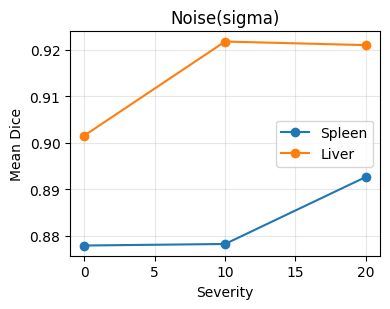

Saved: spleen_vs_liver_pilot.png


In [ ]:
spleen_curves = eval_organ_curves(spleen_triples, "Spleen")
liver_curves  = eval_organ_curves(liver_triples,  "Liver")

plot_spleen_vs_liver(spleen_curves, liver_curves, outpath="spleen_vs_liver_pilot.png")

In [ ]:
!pip -q install git+https://github.com/facebookresearch/segment-anything.git

  Preparing metadata (setup.py) ... done


In [ ]:
!mkdir -p /content/checkpoints
!wget -q -O /content/checkpoints/sam_vit_b_01ec64.pth \
https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

!ls /content/checkpoints

sam_vit_b_01ec64.pth


In [ ]:
import torch
from segment_anything import sam_model_registry, SamPredictor

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

sam = sam_model_registry["vit_b"](
    checkpoint="/content/checkpoints/sam_vit_b_01ec64.pth"
)

sam.to(device=device)

predictor = SamPredictor(sam)

def run_sam_on_slice(rgb_img, box_xyxy):
    predictor.set_image(rgb_img)
    masks, scores, logits = predictor.predict(
        box=box_xyxy[None, :],
        multimask_output=False
    )
    return masks[0].astype("uint8")

print("run_sam_on_slice defined successfully")

Device: cuda
run_sam_on_slice defined successfully


In [ ]:
print("run_sam_on_slice" in globals())

True


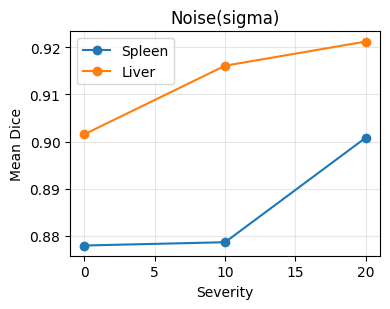

Saved: spleen_vs_liver_pilot.png


In [ ]:
spleen_curves = eval_organ_curves(spleen_triples, "Spleen")
liver_curves  = eval_organ_curves(liver_triples,  "Liver")

plot_spleen_vs_liver(spleen_curves, liver_curves, outpath="spleen_vs_liver_pilot.png")

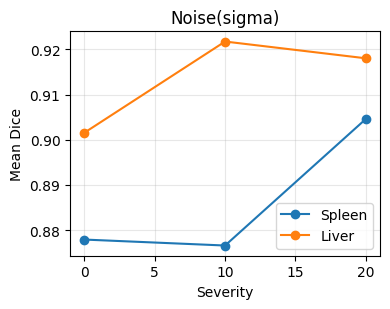

Saved: spleen_vs_liver_pilot.png


In [ ]:
spleen_curves = eval_organ_curves(spleen_triples, "Spleen")
liver_curves  = eval_organ_curves(liver_triples,  "Liver")

plot_spleen_vs_liver(spleen_curves, liver_curves, outpath="spleen_vs_liver_pilot.png")

In [ ]:
!git clone -b SAM-MedicalRobustness_Audit https://github.com/SANGHATI23/sam-brats-robustness-audit.git



Cloning into 'sam-brats-robustness-audit'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 15 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 459.60 KiB | 9.01 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [ ]:
!cp /content/*.ipynb sam_brats_audit.ipynb


cp: cannot stat '/content/*.ipynb': No such file or directory


In [ ]:
%cd sam-brats-robustness-audit


/content/data/sam-brats-robustness-audit


In [ ]:
!cp /content/*.ipynb sam_brats_audit.ipynb


cp: cannot stat '/content/*.ipynb': No such file or directory


In [ ]:
import shutil

shutil.make_archive("sam_project", "zip", "/content")

from google.colab import files
files.download("sam_project.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>